# Chapter 1 — Introduction & Mathematical Foundations

This notebook covers the linear algebra and graph theory tools used throughout the thesis.  
No algorithm is implemented here — this is purely the mathematical scaffolding everything else builds on.

---

## 1.1 Graph Basics

A **graph** $G = (V, E)$ consists of:
- $V$ — a finite set of $n$ nodes (vertices)
- $E$ — a finite set of edges, each connecting two nodes

In this thesis we work exclusively with **undirected, weighted graphs**, where each edge $(i,j) \in E$ carries a weight $w_{ij} > 0$.

### Key matrices

| Matrix | Symbol | Definition |
|--------|--------|------------|
| Weight matrix | $W$ | $W_{ij} = w_{ij}$ if $(i,j) \in E$, else $0$ |
| Degree matrix | $D$ | Diagonal: $D_{ii} = \sum_j W_{ij}$ |
| Laplacian | $L$ | $L = D - W$ |
| Normalized Laplacian | $L_N$ | $L_N = D^{-1/2} L D^{-1/2}$ |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

## 1.2 Example: Weighted Graph and its Matrices

We use the weight matrix from the thesis (Example 1.2) — an 8-node weighted undirected graph.

In [2]:
# Weight matrix W from thesis Example 1.2
W = np.array([
    [0,    0.39, 0.4,  0.15, 0.33, 0,    0.63, 0   ],
    [0.39, 0,    0,    0,    0,    0,    0.92, 0.43],
    [0.4,  0,    0,    0.15, 0.51, 0,    0,    0   ],
    [0.15, 0,    0.15, 0,    0.64, 0.69, 0.15, 0   ],
    [0.33, 0,    0.51, 0.64, 0,    0,    0,    0.25],
    [0,    0,    0,    0.69, 0,    0,    0.6,  0   ],
    [0.63, 0.92, 0,    0.15, 0,    0.6,  0,    0   ],
    [0,    0.43, 0,    0,    0.25, 0,    0,    0   ]
])

# Degree matrix D
degrees = W.sum(axis=1)
D = np.diag(degrees)

# Laplacian L = D - W
L = D - W

# Normalized Laplacian L_N = D^{-1/2} L D^{-1/2}
D_inv_sqrt = np.diag(1.0 / np.sqrt(degrees))
L_N = D_inv_sqrt @ L @ D_inv_sqrt

print("Degree vector (diagonal of D):")
print(np.round(degrees, 4))

print("\nLaplacian L (rounded):")
print(np.round(L, 3))

print("\nNormalized Laplacian L_N (rounded):")
print(np.round(L_N, 3))

Degree vector (diagonal of D):
[1.9  1.74 1.06 1.78 1.73 1.29 2.3  0.68]

Laplacian L (rounded):
[[ 1.9  -0.39 -0.4  -0.15 -0.33  0.   -0.63  0.  ]
 [-0.39  1.74  0.    0.    0.    0.   -0.92 -0.43]
 [-0.4   0.    1.06 -0.15 -0.51  0.    0.    0.  ]
 [-0.15  0.   -0.15  1.78 -0.64 -0.69 -0.15  0.  ]
 [-0.33  0.   -0.51 -0.64  1.73  0.    0.   -0.25]
 [ 0.    0.    0.   -0.69  0.    1.29 -0.6   0.  ]
 [-0.63 -0.92  0.   -0.15  0.   -0.6   2.3   0.  ]
 [ 0.   -0.43  0.    0.   -0.25  0.    0.    0.68]]

Normalized Laplacian L_N (rounded):
[[ 1.    -0.214 -0.282 -0.082 -0.182  0.    -0.301  0.   ]
 [-0.214  1.     0.     0.     0.     0.    -0.46  -0.395]
 [-0.282  0.     1.    -0.109 -0.377  0.     0.     0.   ]
 [-0.082  0.    -0.109  1.    -0.365 -0.455 -0.074  0.   ]
 [-0.182  0.    -0.377 -0.365  1.     0.     0.    -0.23 ]
 [ 0.     0.     0.    -0.455  0.     1.    -0.348  0.   ]
 [-0.301 -0.46   0.    -0.074  0.    -0.348  1.     0.   ]
 [ 0.    -0.395  0.     0.    -0.23   0.    

### Visualize the graph

C:\Users\egoes\AppData\Local\Temp\ipykernel_5900\929575955.py:10: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


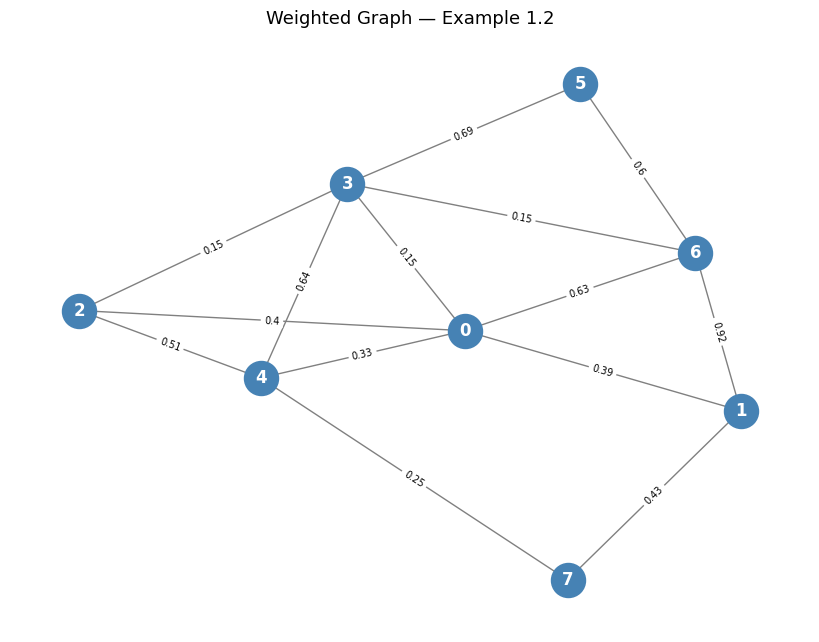

In [3]:
G = nx.from_numpy_array(W)
pos = nx.spring_layout(G, seed=42)
edge_labels = {(i, j): round(W[i][j], 2) for i, j in G.edges()}

plt.figure(figsize=(8, 6))
nx.draw(G, pos, with_labels=True, node_color='steelblue',
        node_size=600, font_color='white', font_weight='bold', edge_color='gray')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=7)
plt.title('Weighted Graph — Example 1.2', fontsize=13)
plt.tight_layout()
plt.show()

---
## 1.3 Properties of the Laplacian

For any vector $\mathbf{f} \in \mathbb{R}^n$:

$$\mathbf{f}^\top L \mathbf{f} = \frac{1}{2} \sum_{i,j} w_{ij}(f_i - f_j)^2$$

This means $L$ is **symmetric** and **positive semi-definite**. Its eigenvalues satisfy:

$$0 = \lambda_1 \leq \lambda_2 \leq \cdots \leq \lambda_n$$

The smallest eigenvalue is always zero, with eigenvector $\mathbf{1} = (1,1,\ldots,1)^\top$.  
The **multiplicity of eigenvalue 0** equals the number of connected components in the graph.

In [4]:
eigenvalues_L, _ = np.linalg.eigh(L)
eigenvalues_LN, _ = np.linalg.eigh(L_N)

print("Eigenvalues of L (sorted):")
print(np.round(eigenvalues_L, 4))

print("\nEigenvalues of L_N (sorted):")
print(np.round(eigenvalues_LN, 4))

print("\nSmallest eigenvalue (should be ~0):", round(eigenvalues_L[0], 10))
print("Positive semi-definite check (all >= 0):", np.all(eigenvalues_L >= -1e-10))

Eigenvalues of L (sorted):
[-0.      0.5797  0.7812  1.0964  1.7978  2.3703  2.6339  3.2206]

Eigenvalues of L_N (sorted):
[-0.      0.4832  0.6043  0.8498  1.3571  1.4469  1.5069  1.7519]

Smallest eigenvalue (should be ~0): -0.0
Positive semi-definite check (all >= 0): True


---
## 1.4 Eigendecomposition and the Spectral Theorem

Since $L$ is real and symmetric, it is **orthogonally diagonalizable**:

$$L = U \Lambda U^\top$$

where $U$ is an orthonormal matrix of eigenvectors and $\Lambda = \text{diag}(\lambda_1, \ldots, \lambda_n)$.

This decomposition is the engine behind all spectral partitioning methods.

In [5]:
eigenvalues, U = np.linalg.eigh(L)
Lambda = np.diag(eigenvalues)

# Verify: L ≈ U @ Lambda @ U.T
L_reconstructed = U @ Lambda @ U.T
reconstruction_error = np.max(np.abs(L - L_reconstructed))

print("Reconstruction error ||L - UΛUᵀ||_max:", round(reconstruction_error, 12))
print("\nFirst 3 eigenvalues:", np.round(eigenvalues[:3], 6))
print("\nFirst eigenvector (should be proportional to [1,1,...,1]):")
print(np.round(U[:, 0], 4))

Reconstruction error ||L - UΛUᵀ||_max: 0.0

First 3 eigenvalues: [-0.        0.579734  0.781233]

First eigenvector (should be proportional to [1,1,...,1]):
[-0.3536 -0.3536 -0.3536 -0.3536 -0.3536 -0.3536 -0.3536 -0.3536]


---
## 1.5 Characteristic Polynomial

For a matrix $A$, the **characteristic polynomial** is:

$$P(\lambda) = \det(A - \lambda I)$$

Its roots are the eigenvalues of $A$. For the simple 3-node complete graph from the thesis (Example 1.4):

$$A_1 = \begin{pmatrix} 2 & -1 & -1 \\ -1 & 2 & -1 \\ -1 & -1 & 2 \end{pmatrix}$$

This is the Laplacian of a complete graph $K_3$.

In [6]:
# ---- Laplacian of K3 (complete graph on 3 nodes) ----
A1 = np.array([
    [ 2, -1, -1],
    [-1,  2, -1],
    [-1, -1,  2]
])

# ---- Characteristic polynomial ----
char_poly_coeffs = np.poly(A1)
print("Characteristic polynomial coefficients (descending degree):")
print(np.round(char_poly_coeffs, 4))
print("  → P(λ) = λ³ + ({})λ² + ({})λ + ({})".format(*np.round(char_poly_coeffs[1:], 4)))
print("\nP(0) =", round(np.polyval(char_poly_coeffs, 0), 4))

# ---- Eigenvalues and eigenvectors ----
eigenvalues_A1, eigenvectors_A1 = np.linalg.eig(A1)
idx = eigenvalues_A1.argsort()[::-1]
eigenvalues_sorted = eigenvalues_A1[idx].real
U = eigenvectors_A1[:, idx]
Lambda_A1 = np.diag(eigenvalues_sorted)

print("\nEigenvalues (descending):", np.round(eigenvalues_sorted, 4))
print("\nEigenvector matrix U:")
print(np.round(U, 4))
print("\nDiagonal eigenvalue matrix Lambda:")
print(np.round(Lambda_A1, 4))

Characteristic polynomial coefficients (descending degree):
[ 1. -6.  9.  0.]
  → P(λ) = λ³ + (-6.0)λ² + (9.0)λ + (0.0)

P(0) = 0.0

Eigenvalues (descending): [ 3.  3. -0.]

Eigenvector matrix U:
[[ 0.3096  0.8165 -0.5774]
 [-0.8091 -0.4082 -0.5774]
 [ 0.4995 -0.4082 -0.5774]]

Diagonal eigenvalue matrix Lambda:
[[ 3.  0.  0.]
 [ 0.  3.  0.]
 [ 0.  0. -0.]]


---
## Summary

| Concept | Key takeaway |
|--------|-------------|
| Weight matrix $W$ | Encodes edge connectivity and strength |
| Degree matrix $D$ | Diagonal — captures how connected each node is |
| Laplacian $L = D - W$ | PSD, symmetric; eigenvalues reveal graph structure |
| Normalized Laplacian $L_N$ | Degree-normalized version; eigenvalues in $[0, 2]$ |
| Eigendecomposition $L = U\Lambda U^\top$ | Foundation of all spectral partitioning methods |
| Smallest eigenvalue = 0 | Always; multiplicity = number of connected components |

**Next:** [Chapter 2 — Spectral Clustering](02_spectral_clustering.ipynb)